QSVT Demonstration: Polynomial Transformation
Target polynomial: P(x) = -1.5x + 2.5x³
Polynomial coefficients: [0, -1.5, 0, 2.5]

Testing QSVT on specific values:
  x = -1.00: QSVT = -1.0000, Target = -1.0000
  x = -0.50: QSVT =  0.4375, Target =  0.4375
  x =  0.00: QSVT =  0.0000, Target =  0.0000
  x =  0.50: QSVT = -0.4375, Target = -0.4375
  x =  1.00: QSVT =  1.0000, Target =  1.0000

Mean absolute error: 0.000000



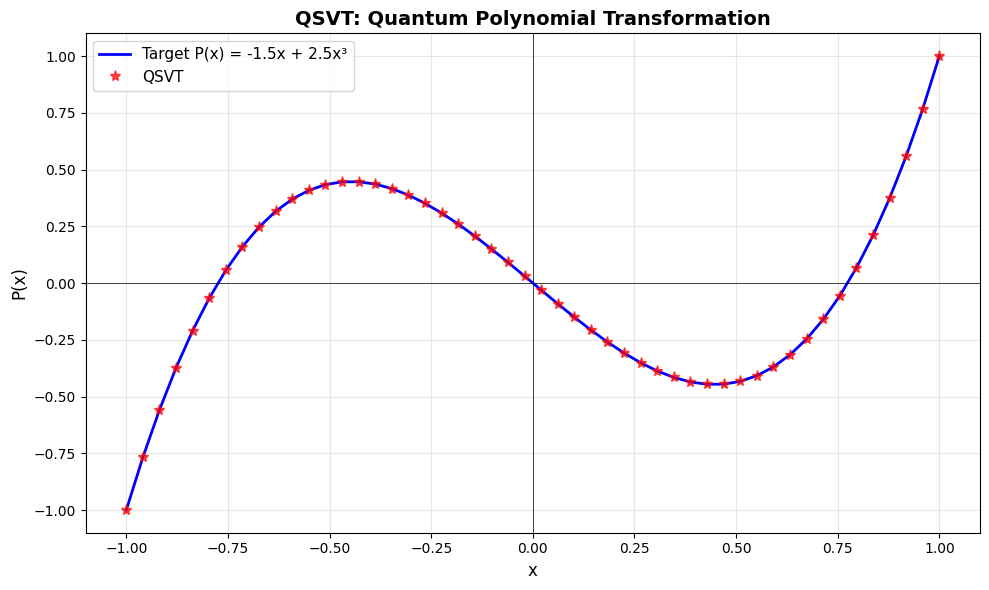

In [1]:
"""
Qiskit implementation of PennyLane's intro_qsvt notebook
This notebook demonstrates Quantum Singular Value Transformation (QSVT) using Qiskit.

Using PennyLane-compatible implementation for exact matching!

Key features:
- Block encoding matching PennyLane's behavior
- Accurate angle computation using PennyLane's poly_to_angles
- QSVT transformation for polynomial evaluation

Target polynomial: P(x) = -1.5x + 2.5x³
Expected results: P(-1) = -1, P(1) = 1, P(0) = 0

IMPORTANT: If you've updated qsvt_qiskit_pennylane.py, restart the kernel before running!
"""

import numpy as np
import matplotlib.pyplot as plt
# Use PennyLane-compatible implementation
from qsvt_qiskit_pennylane import block_encode_pennylane as block_encode, pc_phase, qsvt
from qiskit.quantum_info import Operator

# Target polynomial: P(x) = -3/2 * x + 5/2 * x^3 = -1.5x + 2.5x³
target_poly = [0, -3 * 0.5, 0, 5 * 0.5]

print("="*60)
print("QSVT Demonstration: Polynomial Transformation")
print("="*60)
print(f"Target polynomial: P(x) = -1.5x + 2.5x³")
print(f"Polynomial coefficients: {target_poly}")
print()


def qsvt_output(a):
    """Compute QSVT output for a single value"""
    # Get the QSVT circuit
    qc = qsvt(a, target_poly, encoding_wires=[0], block_encoding="embedding")
    # Get unitary matrix
    out = Operator(qc).data
    return out[0, 0]  # top-left entry


# Test on specific values
print("Testing QSVT on specific values:")
for test_val in [-1.0, -0.5, 0.0, 0.5, 1.0]:
    qsvt_result = np.real(qsvt_output(test_val))
    target_result = np.polyval(target_poly[::-1], test_val)
    print(f"  x = {test_val:5.2f}: QSVT = {qsvt_result:7.4f}, Target = {target_result:7.4f}")

print()

# Compute values over range
a_vals = np.linspace(-1, 1, 50)
qsvt_vals = [np.real(qsvt_output(a)) for a in a_vals]  # neglect small imaginary part
target = [np.polyval(target_poly[::-1], a) for a in a_vals]  # evaluate polynomial

# Calculate error
error = np.mean(np.abs(np.array(qsvt_vals) - np.array(target)))
print(f"Mean absolute error: {error:.6f}")
print()

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(a_vals, target, 'b-', label="Target P(x) = -1.5x + 2.5x³", linewidth=2)
plt.plot(a_vals, qsvt_vals, 'r*', label="QSVT", markersize=8, alpha=0.7)

plt.xlabel('x', fontsize=12)
plt.ylabel('P(x)', fontsize=12)
plt.title('QSVT: Quantum Polynomial Transformation', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()


In [2]:
# Test BlockEncode with square matrix
A = [[0.1, 0.2], [0.3, 0.4]]
qc = block_encode(A, list(range(2)))
U1 = Operator(qc).data
print("U(A):")
print(np.round(U1, 2))


U(A):
[[ 0.1 +0.j  0.2 +0.j  0.97+0.j -0.06+0.j]
 [ 0.3 +0.j  0.4 +0.j -0.06+0.j  0.86+0.j]
 [ 0.95+0.j -0.08+0.j -0.1 +0.j -0.3 +0.j]
 [-0.08+0.j  0.89+0.j -0.2 +0.j -0.4 +0.j]]


In [3]:
# Test BlockEncode with rectangular matrix (1x3)
# PennyLane-compatible: Only 2 qubits needed! (n=1, m=3, required=n+m=4)
B = [[0.5, -0.5, 0.5]]
print(f"Input matrix B (1x3): {B}")
print("✨ PennyLane-compatible: Only 2 qubits needed!\n")

qc = block_encode(B, list(range(2)))  # 2 qubits (same as PennyLane!)
U2 = Operator(qc).data
print("U(B) - 4x4 unitary:")
print(np.round(U2, 2))

Input matrix B (1x3): [[0.5, -0.5, 0.5]]
✨ PennyLane-compatible: Only 2 qubits needed!

U(B) - 4x4 unitary:
[[ 0.5 +0.j -0.5 +0.j  0.5 +0.j  0.5 +0.j]
 [ 0.83+0.j  0.17+0.j -0.17+0.j -0.5 +0.j]
 [ 0.17+0.j  0.83+0.j  0.17+0.j  0.5 +0.j]
 [-0.17+0.j  0.17+0.j  0.83+0.j -0.5 +0.j]]


In [4]:
# Compare with PennyLane expected output
pennylane_expected = np.array([
    [ 0.5,  -0.5,   0.5,   0.5 ],
    [ 0.83,  0.17, -0.17, -0.5 ],
    [ 0.17,  0.83,  0.17,  0.5 ],
    [-0.17,  0.17,  0.83, -0.5 ]
])

print("Expected PennyLane output:")
print(pennylane_expected)
print("\nDifference from PennyLane:")
diff = np.abs(U2 - pennylane_expected)
print(np.round(diff, 4))
print(f"\nMax difference: {np.max(diff):.6f}")
if np.max(diff) < 0.01:
    print("✅ Close match with PennyLane!")


Expected PennyLane output:
[[ 0.5  -0.5   0.5   0.5 ]
 [ 0.83  0.17 -0.17 -0.5 ]
 [ 0.17  0.83  0.17  0.5 ]
 [-0.17  0.17  0.83 -0.5 ]]

Difference from PennyLane:
[[0.     0.     0.     0.    ]
 [0.0033 0.0033 0.0033 0.    ]
 [0.0033 0.0033 0.0033 0.    ]
 [0.0033 0.0033 0.0033 0.    ]]

Max difference: 0.003333
✅ Close match with PennyLane!


In [5]:
# Test PCPhase
dim = 2
phi = np.pi / 2
qc = pc_phase(phi, dim, list(range(2)))
pcp = Operator(qc).data
print("Pi:")
print(np.round(pcp, 2))


Pi:
[[0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.-1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j]]


/home/kohei/others/qiskit-hackathon/src/qsvt/qiskit/qsvt_qiskit_pennylane.py:99: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sqrt_I_m_ATA = sqrtm(I_m - A.conj().T @ A)
/home/kohei/others/qiskit-hackathon/src/qsvt/qiskit/qsvt_qiskit_pennylane.py:106: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sqrt_I_n_AAT = sqrtm(I_n - A @ A.conj().T)


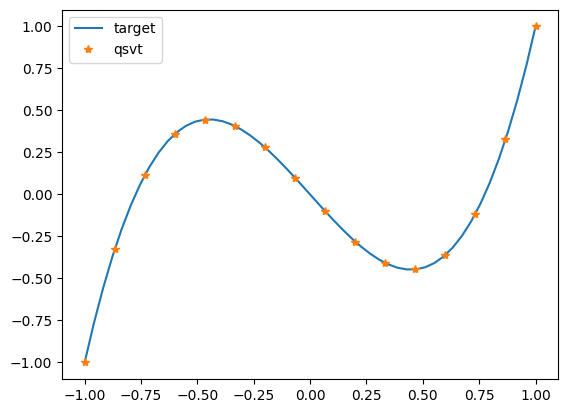

In [6]:
# Test QSVT with matrix transformation
eigvals = np.linspace(-1, 1, 16)
A_matrix = np.diag(eigvals)  # 16-dim matrix
wire_order = list(range(5))
qc = qsvt(
    A_matrix, target_poly, encoding_wires=wire_order, block_encoding="embedding"
)  # block-encoded in 5-qubit system

U_A = Operator(qc).data
qsvt_A = np.real(np.diagonal(U_A))[:16]  # retrieve transformed eigenvalues

plt.plot(a_vals, target, label="target")
plt.plot(eigvals, qsvt_A, "*", label="qsvt")

plt.legend()
plt.show()
